# GREENLY - Model Training Results

Loads the **real** results already produced by `../scripts/train.py` (`../models/metrics.json`) - 5 algorithms x 6 categories, each evaluated on a held-out 20% test split with MAE / RMSE / R^2. Also loads one saved pipeline to show real feature importance and run a live example prediction, exactly as the FastAPI service does at `/api/predict/{category}`.

Run `python ../scripts/train.py` first if `../models/metrics.json` is missing.

In [1]:
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
MODELS = Path('..') / 'models'
metrics = json.loads((MODELS / 'metrics.json').read_text())
print('Categories trained:', list(metrics.keys()))

Categories trained: ['carbon', 'energy', 'electronics', 'water', 'food', 'waste']


## Algorithm comparison across all 6 categories
Every bar below is a real number from an actual held-out test split - not illustrative.

In [2]:
rows = []
for cat, info in metrics.items():
    for algo, m in info['algorithms'].items():
        rows.append({'category': cat, 'algorithm': algo, 'r2': m['r2'], 'mae': m['mae'], 'rmse': m['rmse'],
                     'winner': algo == info['best_algorithm']})
comparison = pd.DataFrame(rows)
comparison.head(10)

,category,algorithm,r2,mae,rmse,winner
0,carbon,random_forest,0.9789,1.9013,4.6189,False
1,carbon,gradient_boosting,0.9824,1.8778,4.2184,True
2,carbon,xgboost,0.9507,2.0171,7.0576,False
3,carbon,lightgbm,0.9574,1.9797,6.5615,False
4,carbon,catboost,0.9535,2.0332,6.8540,False
5,energy,random_forest,0.9937,5.1074,7.6524,False
6,energy,gradient_boosting,0.9982,2.8588,4.0478,False
7,energy,xgboost,0.9984,2.6183,3.8097,False
8,energy,lightgbm,0.9988,2.2836,3.2988,False
9,energy,catboost,0.9993,1.8082,2.5500,True


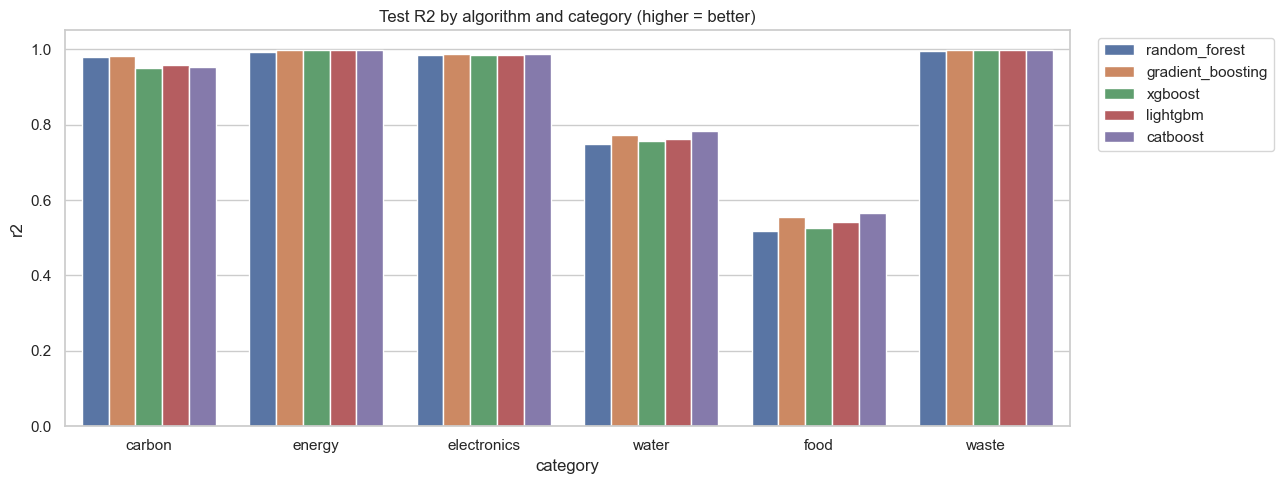

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=comparison, x='category', y='r2', hue='algorithm', ax=ax)
ax.set_ylim(0, 1.05); ax.set_title('Test R2 by algorithm and category (higher = better)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

## Winning model per category

In [4]:
winners = comparison[comparison['winner']][['category', 'algorithm', 'r2', 'mae', 'rmse']]
winners.columns = ['category', 'best_algorithm', 'test_r2', 'test_mae', 'test_rmse']
winners.reset_index(drop=True)

,category,best_algorithm,test_r2,test_mae,test_rmse
0,carbon,gradient_boosting,0.9824,1.8778,4.2184
1,energy,catboost,0.9993,1.8082,2.5500
2,electronics,catboost,0.9875,0.0361,0.0606
3,water,catboost,0.7820,57.7559,77.3752
4,food,catboost,0.5667,11.8450,15.7609
5,waste,catboost,0.9993,0.0521,0.1035


## Feature importance (Carbon model)
What the winning model actually learned mattered.

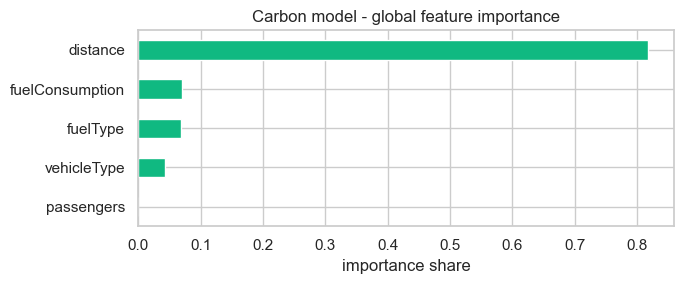

In [5]:
carbon_importance = pd.Series(metrics['carbon']['feature_importance']).sort_values()
fig, ax = plt.subplots(figsize=(7, 3))
carbon_importance.plot.barh(ax=ax, color='#10b981')
ax.set_title('Carbon model - global feature importance'); ax.set_xlabel('importance share')
plt.tight_layout(); plt.show()

## Live example: loading the real saved pipeline and predicting
This is exactly what `app/registry.py` does when the FastAPI service handles `POST /api/predict/carbon`.

In [6]:
pipeline = joblib.load(MODELS / 'carbon_model.joblib')
example = pd.DataFrame([{
    'vehicleType': 'car', 'fuelType': 'petrol', 'distance': 500,
    'fuelConsumption': 8, 'passengers': 1,
}])
prediction = pipeline.predict(example)[0]
print(f'Predicted CO2e for a 500km petrol car trip: {prediction:.1f} kg')

Predicted CO2e for a 500km petrol car trip: 113.2 kg


## Green Score derivation
Not a formula - the predicted value's percentile rank against the real training-target distribution, inverted.

This trip is worse than 97.8% of training trips -> Green Score = 2/100


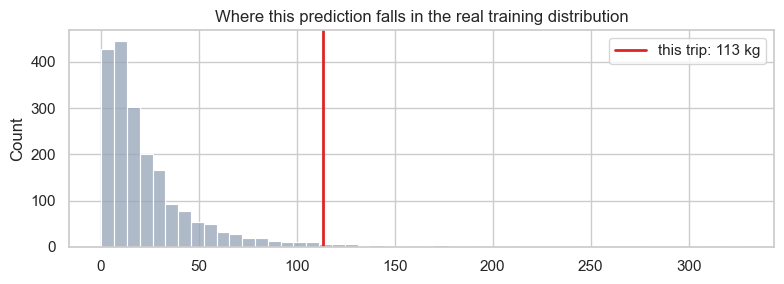

In [7]:
distributions = json.loads((MODELS / 'distributions.json').read_text())
sample = sorted(distributions['carbon']['sorted_sample'])
import bisect
percentile = 100 * bisect.bisect_left(sample, prediction) / len(sample)
green_score = round(100 - percentile)
print(f'This trip is worse than {percentile:.1f}% of training trips -> Green Score = {green_score}/100')

fig, ax = plt.subplots(figsize=(8, 3))
sns.histplot(sample, bins=50, ax=ax, color='#94a3b8')
ax.axvline(prediction, color='#dc2626', linewidth=2, label=f'this trip: {prediction:.0f} kg')
ax.set_title('Where this prediction falls in the real training distribution')
ax.legend(); plt.tight_layout(); plt.show()